# ECG Classification Project

Electrocardiogram (ECG) classification plays acrucial role in diagnosing cardiovascular diseases by analyzing electrical activity of the heart. This project aids to classify ECG iages into different categories .

# **ECG Signal Overview**

An Electrocardiogram (ECG) is a diagnostic tool used to measure and record the electrical activity of the heart over a period of time. It provides crucial information about the heart's rhythm and electrical conduction, making it essential for detecting various cardiac conditions.

**Key Features of an ECG Signal:**

**P wave**: Represents atrial depolarization (contraction of the atria).

**QRS** complex: Corresponds to ventricular depolarization (contraction of the ventricles). It is the most prominent feature in the ECG signal.

**T wave**: Reflects ventricular repolarization (relaxation of the ventricles).

**PR Interval**: The time interval between the onset of the P wave and the start of the QRS complex, indicating the conduction from the atria to the ventricles.

**ST Segment**: The flat section of the ECG between the QRS complex and the T wave, which is crucial for detecting ischemic changes.


**Common Uses of ECG Signals:**

Diagnosis of Arrhythmias: Detect abnormal heart rhythms.

Detection of Myocardial Infarction: Identify heart attacks by observing changes in the ST segment.

Monitoring Cardiac Health: Used in routine check-ups or continuous monitoring in critical care.

# ECG Signal Consists of 12 Leads

*  An Electrocardiogram (ECG) signal consists of 12 leads that capture the
    electrical activity of the heart from different angles. This standard 12-lead ECG system provides a comprehensive view of the heart’s function, helping in the diagnosis of various cardiac conditions.

*  These 12 leads are derived using 10 electrodes placed strategically on the
    body.

# Types of Leads in a 12-Lead ECG

1. Limb Leads (6 leads):

    Bipolar Leads: I, II, III — record electrical differences between two limbs.

    Augmented Leads: aVR, aVL, aVF — use a single positive electrode and a combined reference point.


2. Chest (Precordial) Leads (6 leads):

    Unipolar Leads: V1 to V6 — provide a horizontal view of the heart.


This arrangement allows the ECG to capture both the frontal (vertical) and transverse (horizontal) planes of cardiac activity, providing critical information about the heart's electrical conduction system, rhythm, and potential abnormalities.

# Dataset Overview
**Firstly, MIT- Arrhythmia Dataset contains:**
*   Number of Samples: 109446
*   Number of Categories: 5
*   Sampling Frequency: 125Hz
*   Data Source: Physionet's MIT-BIH Arrhythmia Dataset
*   Classes: ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]
* The final element of each row denotes the class to which that example belongs.


**We read through pandas library .csv file to start processing on it**


 * This Dataset uses **Lead II (MLII)** for most of its recordings. This lead is
    common for detecting arrhythmias due to its clear representation of P, QRS, and T waves.
 * **Lead II** holds significant importance due to its alignment with the
    heart's electrical axis, enabling clear visualization of P waves, QRS complexes, and T waves. Its ability to detect atrial arrhythmias, monitor heart rhythms accurately, and identify inferior myocardial infarctions makes Lead II indispensable in both diagnostic and continuous monitoring settings.”   
 * Using Lead II (MLII) alone can be enough for categorizing ECG signals for
    many arrhythmias since it provides a clear view of P, QRS, and T waves.
   
# Approach:
*  The user uploads an ECG image to our web app.
*  Then, the image will crop to extract lead II , downsample ,and pad with
    zeroes if necessary to the fixed dimension of 188. When the model has completed the analysis, it returns the results to the user based on the findings.

In [77]:
! pip install tensorflow

# Import necessary Libraries


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from skimage.filters import threshold_otsu
from skimage.transform import resize
from skimage.filters import gaussian
import keras
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
#from keras.utils import to_categorical
from sklearn.utils import class_weight
from sklearn.utils import resample
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier , VotingClassifier
from sklearn.tree import DecisionTreeClassifier

# Read the datasets
* Train Dataset
* Test Dataset


In [4]:
! unzip /content/mitbih_train.csv.zip
!unzip /content/mitbih_test.csv.zip

Archive:  /content/mitbih_train.csv.zip
  inflating: mitbih_train.csv        
Archive:  /content/mitbih_test.csv.zip
  inflating: mitbih_test.csv         


In [5]:
train_df = pd.read_csv('/content/mitbih_train.csv', header=None)
test_df = pd.read_csv('/content/mitbih_test.csv', header=None)

# Exploratory Data Analysis (EDA)

In [ ]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print (f'No of images in train_df : {train_df.shape[0]}')
print(f' Each image is of size : {train_df.shape[1]-1}')


No of images in train_df : 87554
 Each image is of size : 187


**Let's show the test_df**

In [ ]:
test_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print (f'No of images in test_df : {test_df.shape[0]}')
print(f' Each image is of size : {test_df.shape[1]-1}')

No of images in test_df : 21892
 Each image is of size : 187


**Getting all info for Train and test datasts**

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 125.6 MB


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21892 entries, 0 to 21891
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 31.4 MB


We get the unique values from the last column that contains all classes and our target, and rename it to become more clear and clarifiable

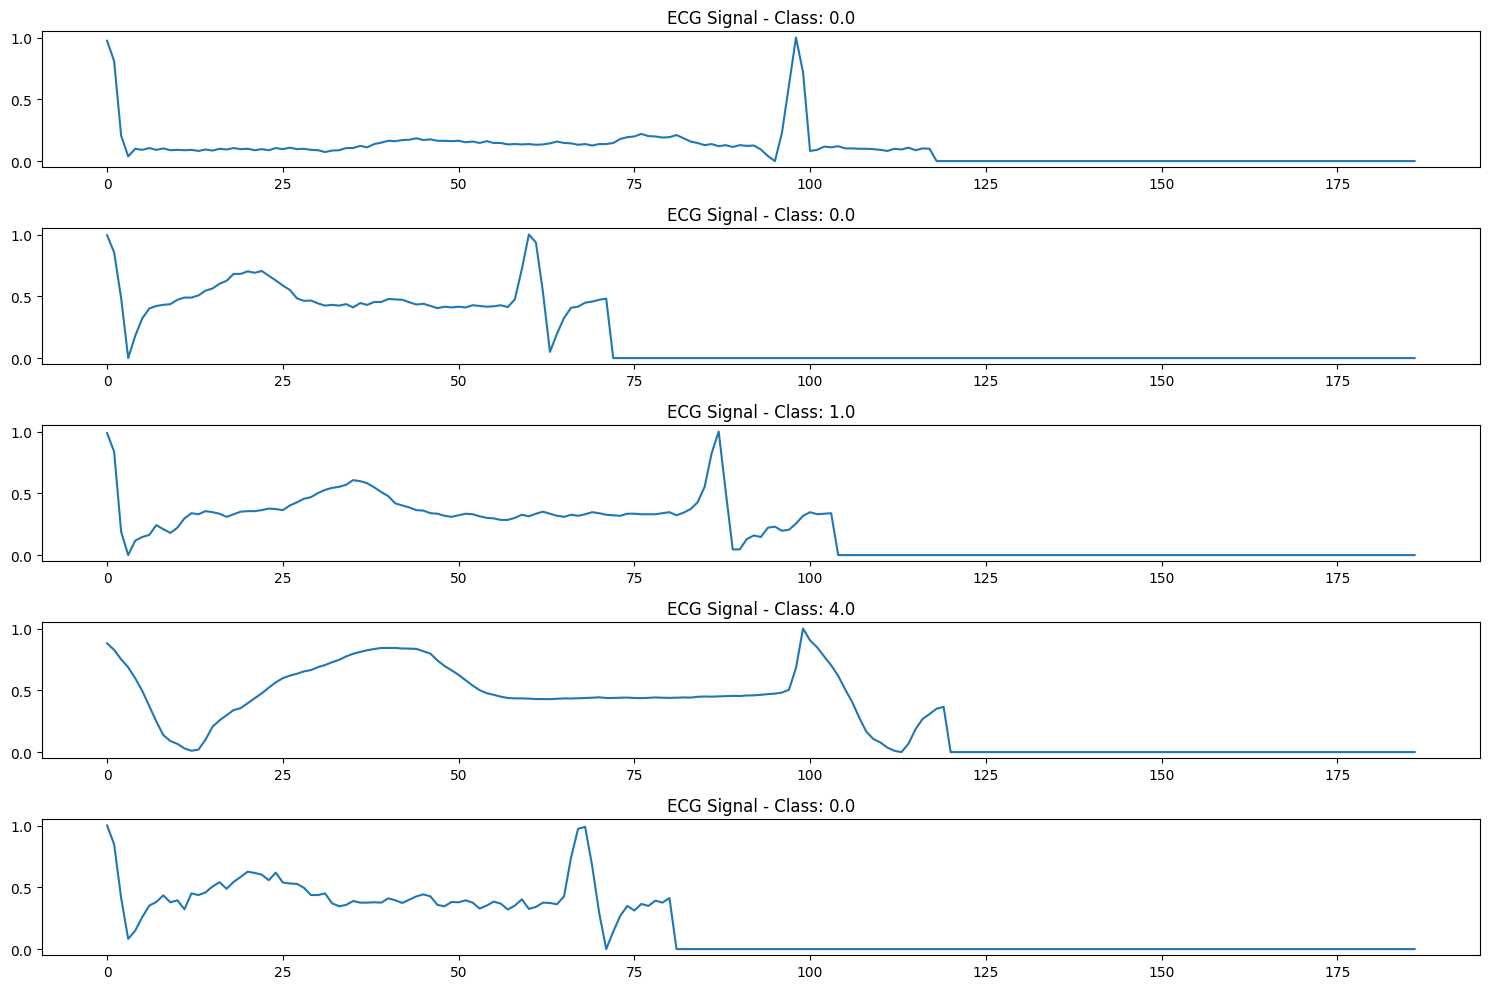

In [ ]:
# Plot Some Random imagesimport matplotlib.pyplot as plt
import random

# Assuming 'train_df' is your DataFrame and the last column contains class labels
num_images_to_plot = 5 # Number of random images to plot

# Get random indices for images
random_indices = random.sample(range(train_df.shape[0]), num_images_to_plot)

# Plot the images
plt.figure(figsize=(15, 10))  # Adjust figure size as needed
for i, index in enumerate(random_indices):
    # Extract the signal data (excluding the last column which is the label)
    signal_data = train_df.iloc[index, :-1].values

    # Create a subplot
    plt.subplot(num_images_to_plot, 1, i+1)

    # Plot the signal
    plt.plot(signal_data)

    # Set title (you can customize this)
    class_label = train_df.iloc[index, -1]  # Get class label
    plt.title(f"ECG Signal - Class: {class_label}")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()


In [ ]:
# As target column is the last column ,let's get the index of that column first
target_column_index = train_df.shape[1] - 1

# Get the unique values in the target column
class_labels = train_df[target_column_index].unique()

# Assign meaningful names to the class labels based on domain knowledge
class_names = {
    0: "Normal Beats",
    1: "Supraventricular Ectopy Beats",
    2: "Ventricular Ectopy Beats",
    3: "Fusion Beats",
    4: "Unclassifiable Beats"
}

# Print class labels with their assigned names
for label in class_labels:
    print(f"Class label {label}: {class_names[label]}")


Class label 0.0: Normal Beats
Class label 1.0: Supraventricular Ectopy Beats
Class label 2.0: Ventricular Ectopy Beats
Class label 3.0: Fusion Beats
Class label 4.0: Unclassifiable Beats


# Null values Percentage

Function for calculating null values

In [ ]:
# Function for calculating null values
def check_null_values(df):
  null_cols =[]
  for col in df.columns:
     null_ratio = train_df[col].isnull().sum()/df.shape[0]
     if null_ratio >0:
       null_cols.append(col)
       print (f"{col} : {null_ratio}")
  if len(null_cols) ==0:
     print('No Null Values columns')



Check train dataset null values

In [ ]:
check_null_values(train_df)

No Null Values columns


ok ,There is Non Null vaues in the train_df

Let's Check Test dataframe

In [ ]:
check_null_values(test_df)

No Null Values columns


 **get the unique values in the last column to see how many images in every class**

In [ ]:
train_distribution = train_df[target_column_index].value_counts()
print(train_distribution)

187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64


#  pie chart
*  plot pie chart that explain every class with its perecentages in the  
    training and test  dataset

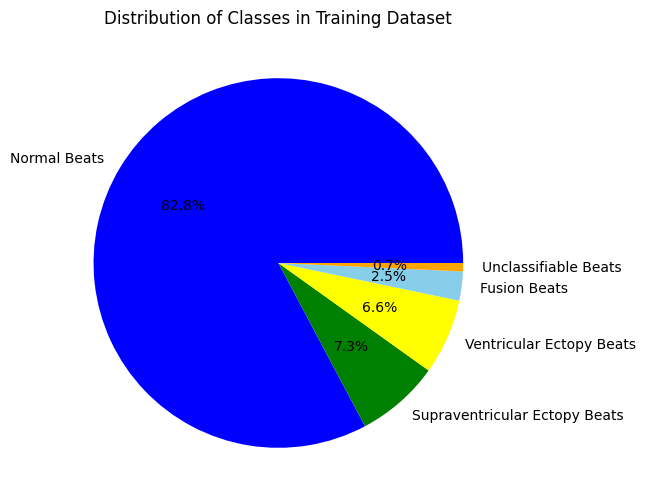

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(train_distribution,
        labels=['Normal Beats',
                'Supraventricular Ectopy Beats',
                'Ventricular Ectopy Beats',
                'Fusion Beats','Unclassifiable Beats'],
         colors=['Blue','Green','Yellow','Skyblue','Orange'],
        autopct='%1.1f%%', textprops={'color': 'black'})
plt.title("Distribution of Classes in Training Dataset")
plt.show()

*  The dataset is imbalanced since Normal beats are much more frequent than
    others,and that could led for overfitting which might affect the model's accuracy.
*  To fix this, I actually tried two methods for balancing the dataset:

1. SMOTE: To generate synthetic samples for the minority class.


2. Resampling: By  oversampling the minority class(to 20000 samples each    
    class ) .



* I found that the accuracy was higher with resampling.

* so I used it and left the SMOTE code as a comment to explain the steps I took.


In [ ]:
'''
# balacing train datafram using SMOTE
from imblearn.over_sampling import SMOTE
import pandas as pd
df_1 = train_df[train_df[187] == 1]
df_2 = train_df[train_df[187] == 2]
df_3 = train_df[train_df[187] == 3]
df_4 = train_df[train_df[187] == 4]
# creates a DataFrame (df_0) by randomly sampling 20,000 instances from the majority class (class 0).
df_0 = train_df[train_df[187]==0].sample(n =20000, random_state=123)
train_df = pd.concat([df_0, df_1, df_2, df_3, df_4])
# Separate features and labels
X = train_df.drop(columns=[187])  #  column 187 is the label
y = train_df[187]

# Define desired number of samples for each class
sampling_strategy = {0: 20000, 1: 20000, 2: 20000, 3: 20000, 4: 20000}

# Apply SMOTE with custom sample sizes
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=123)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine the resampled data into a new DataFrame
train_df = pd.concat([pd.DataFrame(X_resampled), pd.Series(y_resampled, name=187)], axis=1)'''


# Resampling train datafram

1.  filtering train_df[187].
   * It grouping train_df with the value in column 187 , this column holds the
         class labels.

In [6]:
df_1 = train_df[train_df[187] == 1]
df_2 = train_df[train_df[187] == 2]
df_3 = train_df[train_df[187] == 3]
df_4 = train_df[train_df[187] == 4]

2. OverSamling the minority classes to 20000
3. Downsampling the majority class to 20000

In [7]:

df_1_upsample = resample(df_1, n_samples = 20000, replace = True, random_state = 123)
df_2_upsample = resample(df_2, n_samples = 20000, replace = True, random_state = 123)
df_3_upsample = resample(df_3, n_samples = 20000, replace = True, random_state = 123)
df_4_upsample = resample(df_4, n_samples = 20000, replace = True, random_state = 123)
df_0 = train_df[train_df[187]==0].sample(n =20000, random_state=123)
train_df = pd.concat([df_0, df_1_upsample, df_2_upsample, df_3_upsample, df_4_upsample])

**Pie Chart shows the training dataset after resampling**

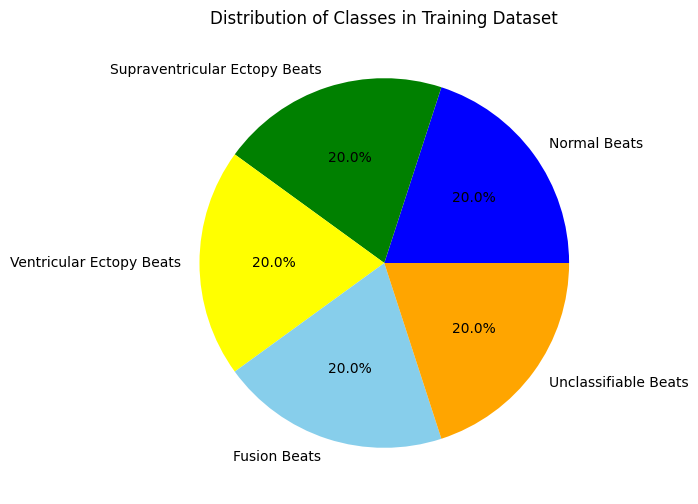

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(train_df[187].value_counts(),
        labels=['Normal Beats',
                'Supraventricular Ectopy Beats',
                'Ventricular Ectopy Beats',
                'Fusion Beats','Unclassifiable Beats'],
         colors=['Blue','Green','Yellow','Skyblue','Orange'],
        autopct='%1.1f%%', textprops={'color': 'black'})
plt.title("Distribution of Classes in Training Dataset")
plt.show()

In [ ]:
print(train_df[187].value_counts())
print(len(train_df[187].value_counts()))

187
0.0    20000
1.0    20000
2.0    20000
3.0    20000
4.0    20000
Name: count, dtype: int64
5


# Preprocessing

**split train_df into X_train and y_train**


In [8]:
X_train = train_df.drop(columns = [187])
y_train = train_df[187]

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)
# Separate features and target variable for test dataset
X_test = test_df.drop(columns=[187])
y_test = test_df[187]

**Use standard scaler function to normalize our training dataset and transform only on valid and test**

In [10]:
# Initialize the StandardScaler
scaler = StandardScaler()
# Fit the scaler to the training data and transform it
X_train_normalized = scaler.fit_transform(X_train)
# Transform the scaler to validation data
X_val_normalized = scaler.transform(X_val)
# Transform the test data using the fitted scaler
X_test_normalized = scaler.transform(X_test)


# Machine Learning Classifiers

In [11]:
# Function for calculiting acuuracy ,precision,recall
def calculate_metrics(classifier) :
   y_pred_val = classifier.predict(X_val_normalized)
   # Calculate accuracy on the validation set
   accuracy_val = accuracy_score(y_val, y_pred_val)
   print(f"Validation Accuracy: {accuracy_val*100:.2f}%")
   y_pred_test = classifier.predict(X_test_normalized)
   # calculate precision in val set
   precision_val = precision_score(y_val, y_pred_val, average='weighted')
   print(f"Validation Precision: {precision_val*100 :.2f} %")

   #calculate recall on val set
   recall_val = recall_score(y_val, y_pred_val, average='weighted')
   print(f"Validation Recall: {recall_val*100 :.2f} %")

   # Calculate accuracy on the testing set
   accuracy_test = accuracy_score(y_test, y_pred_test)
   print(f"Testing  Accuracy: {accuracy_test*100:.2f}%")

   # Calculate precision
   precision_test = precision_score(y_test, y_pred_test, average='weighted')
   print(f"testing Precision: {precision_test*100:.2f}%")

   # Calculate recall
   recall_test = recall_score(y_test, y_pred_test, average='weighted')
   print(f"testing Recall:{recall_test*100 :.2f} %")

# Support Vector Machine (SVM) Model

**It is a supervised machine learning algorithm which can be used for both classification and regression problems. However, it is mostly used in classification applications.**
*  The classification is performed by finding the hyperplane that best  
    separates the two classes.

  * Select the hyper-plane which separate the two classes better.
  * Maximizing the distance between nearest data point (either class) and the
    hyper-plane. This distance is called Margin.
  * Margin: it is the distance between the hyperplane and the observations      closest to the hyperplane (support vectors).
  * Support Vectors: These are the points that are closest to the hyperplane.
  *  A separating line will be defined with the help of these data points.

In [ ]:
# Create the SVM classifier
svm_classifier = svm.SVC(kernel='rbf', random_state=42)

# Train the classifier on the normalized training data
svm_classifier.fit(X_train_normalized, y_train)

SVC(random_state=42)

In [ ]:
calculate_metrics(svm_classifier)

Validation Accuracy: 94.07%
Validation Precision: 94.14 %
Validation Recall: 94.07 %
Testing  Accuracy: 90.46%
testing Precision: 95.45%
testing Recall:90.46 %


# Random Forest

* Random forest classifier is a popular machine learning algorithm used for  
   both classification and regression tasks
* It's an ensemble learning method that operates by constructing a multitude of
  decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees

In [12]:
# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=101, random_state=123)

# Train the classifier using extracted features and corresponding labels
rf_classifier.fit(X_train_normalized, y_train)


RandomForestClassifier(n_estimators=101, random_state=123)

In [13]:
calculate_metrics(rf_classifier)

Validation Accuracy: 99.63%
Validation Precision: 99.64 %
Validation Recall: 99.63 %
Testing  Accuracy: 97.55%
testing Precision: 97.51%
testing Recall:97.55 %


# Decision Tree (DT) Model

* Decision trees being one of the most popular and effective techniques used to
   solve classification problems.
* It is important to prioritize the features when creating a tree.

In [ ]:
# Create the Decision Tree classifier
clf_dt = DecisionTreeClassifier(random_state=42)

# Train the classifier on the normalized training data
clf_dt.fit(X_train_normalized, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
calculate_metrics(clf_dt)

Testing  Accuracy: 92.18%
testing Precision: 93.63%
testing Recall:92.18 %


# Ensemble Model (Voting)

A voting classifier is a machine learning model that combines the predictions of several other individual models, also known as an ensemble method. Instead of relying on a single model, it leverages the strengths of various models to arrive at a more robust prediction.

In [ ]:
# Create the voting ensemble
voting_clf = VotingClassifier(estimators=[('decision_tree', clf_dt), ('rf', rf_classifier), ('support_vector_machine', svm_classifier)], voting='hard')

# Train the voting ensemble on the normalized training data
voting_clf.fit(X_train_normalized, y_train)


VotingClassifier(estimators=[('decision_tree',
                              DecisionTreeClassifier(random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=123)),
                             ('support_vector_machine', SVC(random_state=42))])

In [ ]:
calculate_metrics(voting_clf)

Testing  Accuracy: 96.92%
testing Precision: 97.01%
testing Recall:96.92 %


The best module is Random Forest

# Random Search

I will make Randomizes Search on the best Model Score (Random Forest)

In [ ]:
# prompt: parameter for random search for rf

from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for random search
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],

}

# Create a random forest classifier
rf_classifier = RandomForestClassifier(random_state=123)

# Perform random search with cross-validation
random_search = RandomizedSearchCV(
    rf_classifier, param_distributions=param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=123, n_jobs=-1
)

# Fit the random search to the training data
random_search.fit(X_train_normalized, y_train)

# Get the best hyperparameters
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# Evaluate the best model
best_rf_classifier = random_search.best_estimator_
calculate_metrics(best_rf_classifier)


In [ ]:
best_model = random_search.best_estimator_
calculate_metrics(best_model)

Validation Accuracy: 99.53%
Validation Precision: 99.53 %
Validation Recall: 99.53 %
Testing  Accuracy: 97.36%
testing Precision: 97.37%
testing Recall:97.36 %


# Save the best model
**Random Forest is the best model I tested untill now**

In [14]:
from joblib import dump, load
import os

# Save the model in the current directory
current_directory = os.getcwd()
file_path = os.path.join(current_directory, 'ECG_model.joblib')
dump(rf_classifier, file_path)

# Verify if the file was created successfully
if os.path.exists(file_path):
    print(f"Model saved successfully at: {file_path}")
else:
    print(f"Error saving model at: {file_path}")

from google.colab import files
files.download(file_path) # Ensure you are downloading the saved file


Model saved successfully at: /content/ECG_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# plot Confusion Matrix

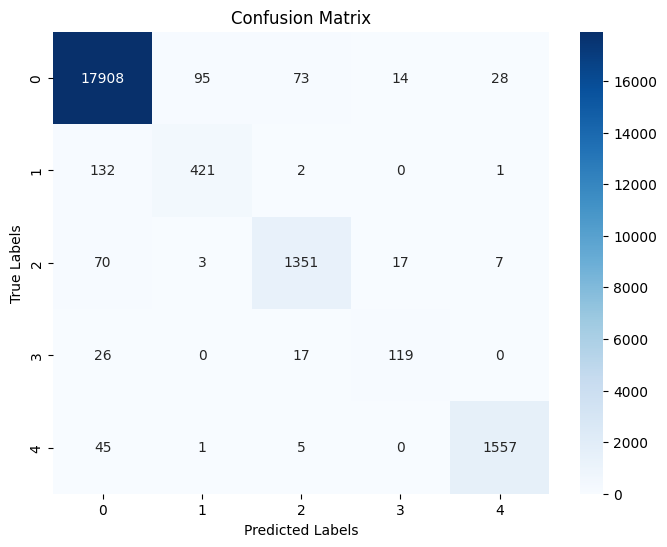

In [15]:
y_pred_test = rf_classifier.predict(X_test_normalized)
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

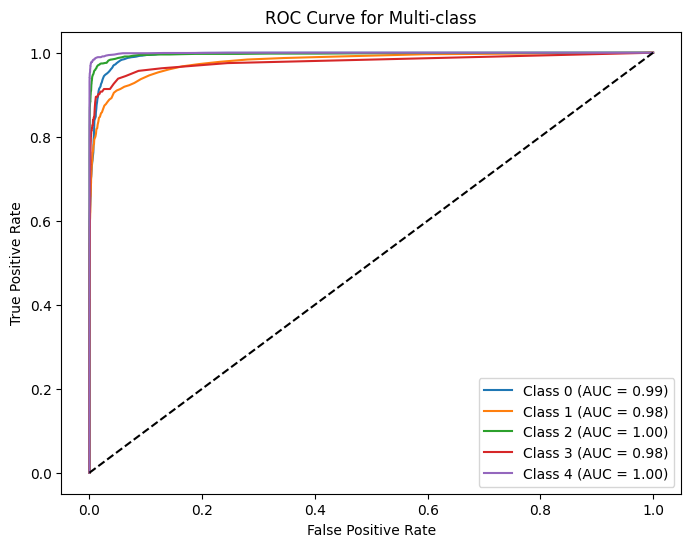

In [24]:
#  plot AUC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize the output
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
n_classes = y_test_binarized.shape[1]

y_pred_proba = rf_classifier.predict_proba(X_test_normalized)


# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Add a diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-class')
plt.legend(loc='lower right')
plt.show()

In [25]:
# Function to extract lead_II from an image depends on coordinates
# Cropped EcG image to extract each lead
def extract_leads(sample_image_path):
    image = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
    plt.subplot(3, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title('Original Image')

    lead_II = image[600:900, 140:630]  # Records from the right arm to the left legs
    plt.subplot(3, 2, 2)
    plt.imshow(lead_II, cmap='gray')
    plt.axis('off')
    plt.title('Lead II')

    # Apply Gaussian filtering to smooth the image
    blurred_image = gaussian(lead_II, sigma=0.7)

    # Apply Otsu's thresholding to distinguish foreground and background
    global_threshold = threshold_otsu(blurred_image)
    binary_image = blurred_image < global_threshold
    plt.subplot(3, 2, 3)
    plt.imshow(binary_image, cmap='gray')
    plt.axis('off')
    plt.title('Binary Image')

    # Resize the binary image
    binary_image = resize(binary_image, (300, 300))
    plt.subplot(3, 2, 4)
    plt.imshow(binary_image, cmap='gray')
    plt.axis('off')
    plt.title('Resized Binary Image')

    # Resize the binary image to have 186 columns
    binary_image_resized = resize(binary_image, (binary_image.shape[0], 187))

    # Convert the binary image to a signal by summing pixel values along rows
    x_signal = np.sum(binary_image_resized, axis=0)

    # Reshape the signal to a 2D array for the model
    x_signal_reshaped = x_signal.reshape(1, -1)  # Reshape to (1, 186)
    plt.subplot(3,2,5)
    plt.plot(x_signal_reshaped[0])
    plt.title('Reshaped Signal')
    plt.show()
    # Normalize the signal using the scaler

    normalized_x_signal = scaler.transform(x_signal_reshaped)
    return normalized_x_signal


In [30]:
class_labels = {0: 'Normal Beats', 1: 'Supraventricular Ectopy Beats', 2: 'Ventricular Ectopy Beats', 3: 'Fusion Beats', 4: 'Unclassifiable Beats'}

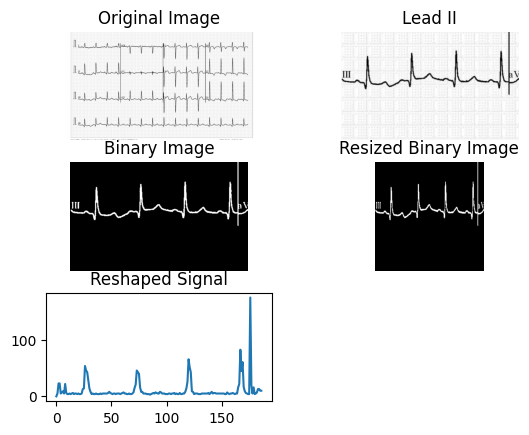

Prediction: Ventricular Ectopy Beats


In [35]:
lead_II_signal = extract_leads('/content/abnormal.jpg')

prediction =rf_classifier.predict(lead_II_signal)
prediction = class_labels[prediction[0]]
print(f"Prediction: {prediction}")
